# Steane Circuit Level Noise (single round)

Data generation and analysis
    + different decoder: ML, MWPM
    + different distances
    + different noise levels

analysis: 
    + show asymptotic behavior
    + determine thresholds


In [4]:
import os
import numpy as np

from tools.file import read_config, write_config, read_folder, get_standard_config
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

from tools.parameter import PATH_TO_CONFIG_FOLDER

## Config Definitions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Circuit level noise with different noise levels

Decoding both in ML and MWPM


In [2]:
# Main parameters:
num_shots_ML = 1_000
num_shots_MWPM = 10_000

noise_rates = [float(x) for x in np.logspace(-2.0,-0.8,dtype=float)]
distances = [3,5,7,9,11,13,15]

# TODO could make the config definition less verbose

In [3]:
# ML Config (Z)
folder_name_ML_Z = "circ_md_1r_steane_Z_ML"

configuration_ML_Z =  {
    "circuit": {
        "distances":  distances,      # list of odd number >= 3
        "qec_rounds":       [1,],      # list of natural numbers
        "observable":   "Z",    # "Z" or "X" (maybe later also "B" for both)
        # not yet implemented
        "order":        "0p",   # order of ancilla CNOTs "0p", "p0" 
        "type": "steane",       # later also multiple rounds of surface code
        # redundant:
        "inital_state": "0",    # "0" or "p" (maybe later also "B" for bell state)
        "special_parameter": {},# open for future references
    },
    "noise_model": {
        "type": "circ",     # noise model: "circ", "bit_flip", "phase_flip", "basic" # this string defines the function that is gonna be used
        "noise_rates":    noise_rates,    # list of error rates
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type": "ml",           # "ml" or "mwpm"
    },
    "sampling": {
        "num_shots": num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
write_config(configuration_ML_Z,folder_name_ML_Z,backup=True)

In [4]:
# Generate ML Data (Z)
if False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_ML_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_ML_Z)

In [5]:
# ML Config (X)
folder_name_ML_X = "circ_md_1r_steane_X_ML"

configuration_ML_X =  {
    "circuit": {
        "distances":        distances,      # list of odd number >= 3
        "qec_rounds":       [1,],      # list of natural numbers
        "observable":       "X",    # "Z" or "X" (maybe later also "B" for both)
        # not yet implemented
        "order":            "0p",   # order of ancilla CNOTs "0p", "p0" 
        "type":             "steane",       # later also multiple rounds of surface code
        # redundant:
        "inital_state":     "p",    # "0" or "p" (maybe later also "B" for bell state)
        "special_parameter": {},# open for future references
    },
    "noise_model": {
        "type": "circ",     # noise model: "circ", "bit_flip", "phase_flip", "basic" # this string defines the function that is gonna be used
        "noise_rates":      noise_rates ,    # list of error rates
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type": "ml",           # "ml" or "mwpm"
    },
    "sampling": {
        "num_shots": num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
write_config(configuration_ML_X,folder_name_ML_X,backup=True)

In [6]:
# Generate ML Data (X)
if False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_ML_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_ML_X)

In [7]:
# MWPM Config (Z)
folder_name_MWPM_Z = "circ_md_1r_steane_Z_MWPM"

configuration_MWPM_Z =  {
    "circuit": {
        "distances":    distances,      # list of odd number >= 3
        "qec_rounds":       [1,],      # list of natural numbers
        "observable":   "Z",    # "Z" or "X" (maybe later also "B" for both)
        # not yet implemented
        "order":        "0p",   # order of ancilla CNOTs "0p", "p0" 
        "type": "steane",       # later also multiple rounds of surface code
        # redundant:
        "inital_state": "0",    # "0" or "p" (maybe later also "B" for bell state)
        "special_parameter": {},# open for future references
    },
    "noise_model": {
        "type": "circ",     # noise model: "circ", "bit_flip", "phase_flip", "basic" # this string defines the function that is gonna be used
        "noise_rates":    noise_rates,    # list of error rates
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type": "mwpm",           # "ml" or "mwpm"
    },
    "sampling": {
        "num_shots": num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
write_config(configuration_MWPM_Z,folder_name_MWPM_Z,backup=True)

In [8]:
# Generate MWPM data (Z)
if False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_MWPM_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_MWPM_Z)

In [9]:
# MWPM Config (X)
folder_name_MWPM_X = "circ_md_1r_steane_X_MWPM"

configuration_MWPM_X =  {
    "circuit": {
        "distances":    distances,      # list of odd number >= 3
        "qec_rounds":       [1,],      # list of natural numbers
        "observable":   "X",    # "Z" or "X" (maybe later also "B" for both)
        # not yet implemented
        "order":        "0p",   # order of ancilla CNOTs "0p", "p0" 
        "type": "steane",       # later also multiple rounds of surface code
        # redundant:
        "inital_state": "p",    # "0" or "p" (maybe later also "B" for bell state)
        "special_parameter": {},# open for future references
    },
    "noise_model": {
        "type": "circ",     # noise model: "circ", "bit_flip", "phase_flip", "basic" # this string defines the function that is gonna be used
        "noise_rates":    noise_rates,    # list of error rates
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type": "mwpm",           # "ml" or "mwpm"
    },
    "sampling": {
        "num_shots": num_shots_MWPM,       # number of shots per configuration
    },
}
# write config to file
write_config(configuration_MWPM_X,folder_name_MWPM_X,backup=True)

In [10]:
# Generate MWPM data
if False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, folder_name_MWPM_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=folder_name_MWPM_X)

## Analysis 

+ Find thresholds
+ Map asymptotic behavior, show change in distances

In [1]:
# read data from files
folder_name_ML_Z = "circ_md_1r_steane_Z_ML"
folder_name_ML_X = "circ_md_1r_steane_X_ML"
folder_name_MWPM_Z = "circ_md_1r_steane_Z_MWPM"
folder_name_MWPM_X = "circ_md_1r_steane_X_MWPM"

In [5]:
def analysis_pipeline(folder_name):
    config, data = read_folder(folder_name_ML_X)
    guess_nu = [1.5]
    guess_pth = [0.01]
    data = data_pre_processing(data)
    data = determine_threshold(data,guess_nu=guess_nu,guess_pth=guess_pth)
    data_plot_log_error_rates(data)
    data_plot_fssa_results(data)


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 17.517963142869164
             x: [ 1.100e-02  6.325e-01]
           nit: 60
          nfev: 127
 final_simplex: (array([[ 1.100e-02,  6.325e-01],
                       [ 1.100e-02,  6.325e-01],
                       [ 1.100e-02,  6.325e-01]]), array([ 1.752e+01,  1.752e+01,  1.752e+01]))


/home/leo/Documents/MasterArbeit/code/tools/fssa.py:17: RuntimeWarning: invalid value encountered in divide
  y_bar = ((x2 - x1) * y0 - (x0 - x1) * y2) / (x2 - x0)
/home/leo/Documents/MasterArbeit/code/tools/fssa.py:18: RuntimeWarning: invalid value encountered in divide
  delta_sq = (e1**2 + (e0 * (x2 - x1) / (x2 - x0))**2 + (e2 * (x0 - x1) / (x2 - x0))**2)


<Figure size 640x480 with 0 Axes>

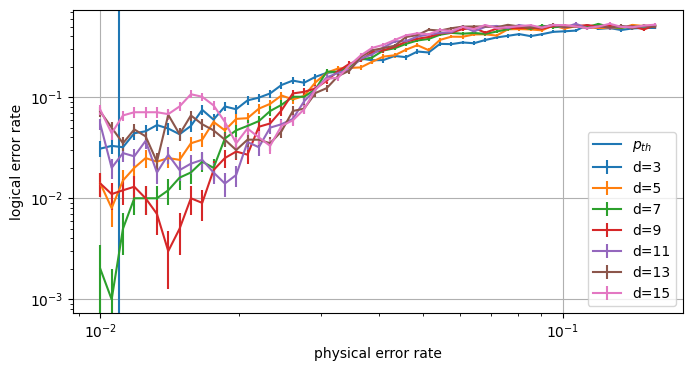

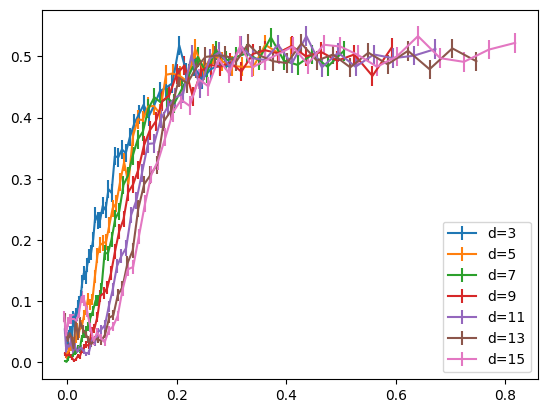

In [6]:
analysis_pipeline(folder_name_ML_X)